In [1]:
import pandas as pd
import numpy as np

### Uploading a Dataset

YouTo upload files from your local system to Colab, you can use `files.upload()` from `google.colab`. This will prompt you to select a file from your computer.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving creditcard_fraud.csv to creditcard_fraud.csv


Once the file is uploaded, you can load it into a pandas DataFrame. Assuming you uploaded a CSV file, you can do so like this:

In [3]:
df=pd.read_csv("creditcard_fraud.csv")
df.head()

,cardholder_name,card_number,merchant_name,merchant_category,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud
0,Allison Hill,4961023726432058,"Merchant: Calhoun, Davis and Richmond",grocery,189.90,6,0.63,1,1,1,0
1,Noah Rhodes,4997245971557937,Merchant: Powell and Sons,online_shopping,14.50,15,1.12,0,0,2,0
2,Angie Henderson,4770115491773269,Merchant: Cox-Mejia,dining,23.46,16,27.38,1,0,0,0
3,Daniel Wagner,4968568888610852,"Merchant: Ortiz, Snow and Garner",grocery,30.00,6,5.75,1,0,0,0
4,Cristian Santos,4358679433644706,Merchant: Barker PLC,grocery,63.56,17,0.42,1,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cardholder_name     10000 non-null  object 
 1   card_number         10000 non-null  int64  
 2   merchant_name       10000 non-null  object 
 3   merchant_category   10000 non-null  object 
 4   amount              10000 non-null  float64
 5   hour                10000 non-null  int64  
 6   distance_from_home  10000 non-null  float64
 7   is_online           10000 non-null  int64  
 8   is_foreign          10000 non-null  int64  
 9   velocity_last_hour  10000 non-null  int64  
 10  is_fraud            10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [5]:
df.drop(columns=['cardholder_name','card_number','merchant_name'],inplace=True)

In [6]:
tracs=df["is_fraud"].value_counts()

<Axes: >

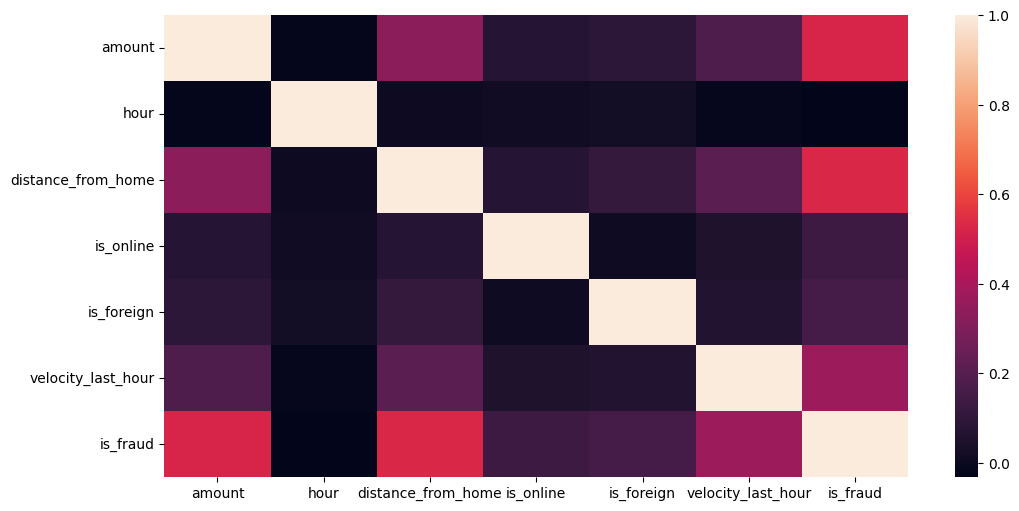

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True))

In [8]:
df=pd.get_dummies(df,columns=['merchant_category'],drop_first=True)

In [9]:
df.head()

,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud,merchant_category_electronics,merchant_category_gas_station,merchant_category_grocery,merchant_category_online_shopping,merchant_category_travel
0,189.90,6,0.63,1,1,1,0,False,False,True,False,False
1,14.50,15,1.12,0,0,2,0,False,False,False,True,False
2,23.46,16,27.38,1,0,0,0,False,False,False,False,False
3,30.00,6,5.75,1,0,0,0,False,False,True,False,False
4,63.56,17,0.42,1,0,1,0,False,False,True,False,False


In [10]:
X=df.drop(columns=['is_fraud'])
y=df['is_fraud']

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [12]:
X_train

,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,merchant_category_electronics,merchant_category_gas_station,merchant_category_grocery,merchant_category_online_shopping,merchant_category_travel
3209,18.26,7,6.62,1,0,0,False,False,False,False,False
6276,41.02,18,18.01,1,0,2,False,True,False,False,False
8953,23.08,8,2.82,0,0,0,True,False,False,False,False
4780,8.32,15,19.05,0,0,1,False,False,True,False,False
2470,105.54,10,4.55,0,0,0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
6652,20.12,11,3.76,1,0,1,False,False,False,False,False
301,23.91,16,56.63,1,0,1,False,False,False,True,False
6437,1129.51,2,8.78,1,0,5,True,False,False,False,False
6212,30.15,13,24.25,0,0,1,False,False,True,False,False


In [13]:
y_train

,is_fraud
3209,0
6276,0
8953,0
4780,0
2470,0
...,...
6652,0
301,0
6437,1
6212,0


In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
rf=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

In [16]:
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [17]:
rf_pred=rf.predict(X_test)


In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [19]:
rf_accuracy=accuracy_score(y_test,rf_pred)
print(rf_accuracy)

0.9955


In [20]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1966
           1       1.00      0.74      0.85        34

    accuracy                           1.00      2000
   macro avg       1.00      0.87      0.92      2000
weighted avg       1.00      1.00      1.00      2000



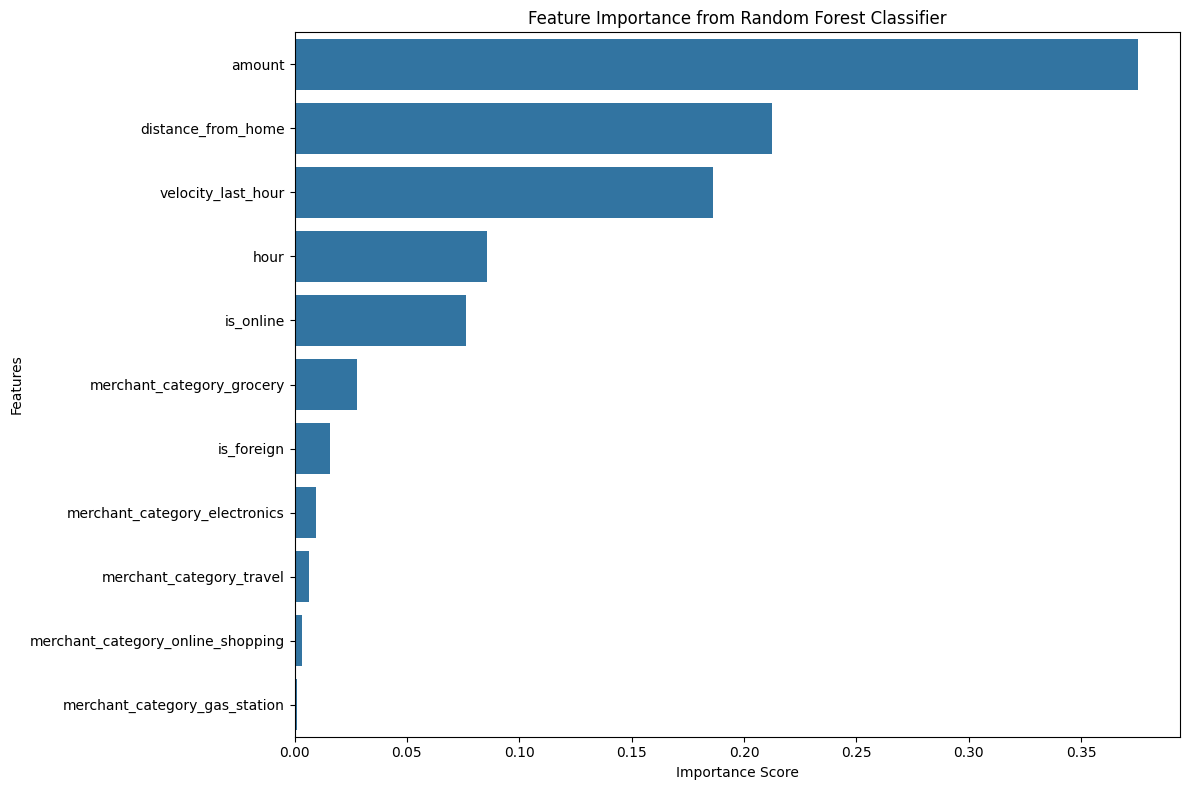

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = rf.feature_importances_

# Create a pandas Series for better visualization
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort the features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

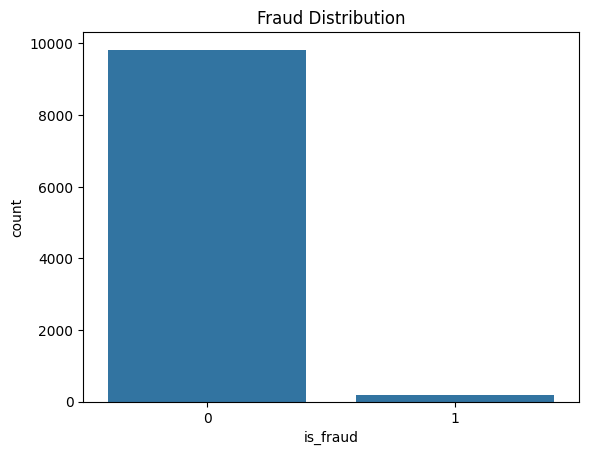

In [22]:
sns.countplot(x='is_fraud',data=df)
plt.title('Fraud Distribution')
plt.show()

Text(0, 0.5, 'Frequency')

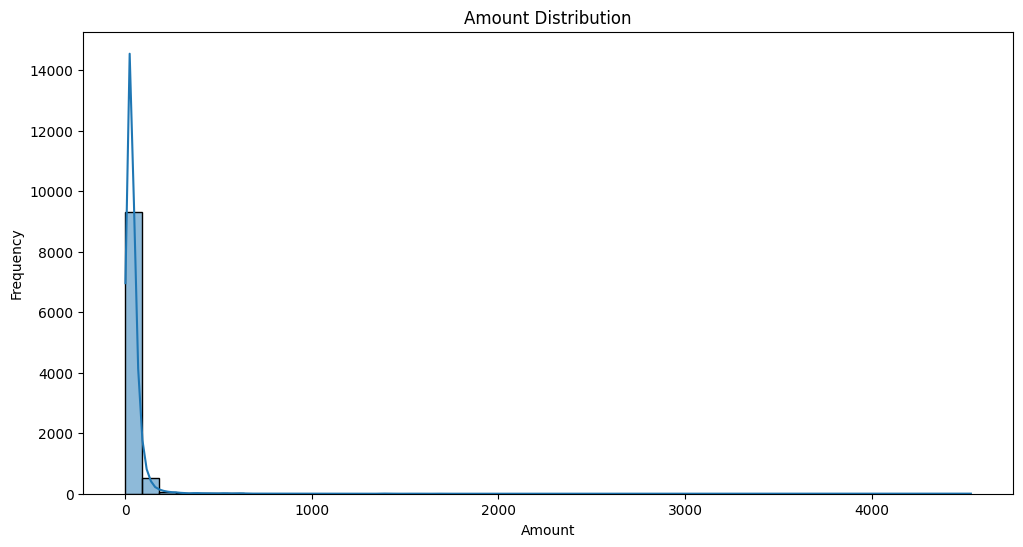

In [24]:
plt.figure(figsize=(12,6))
sns.histplot(df['amount'],bins=50,kde=True)
plt.title('Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

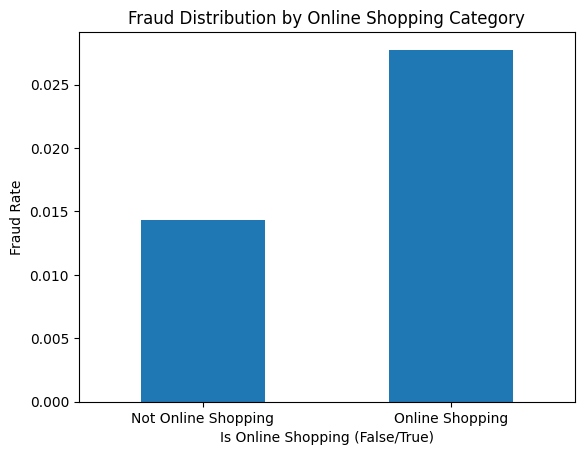

In [25]:
fraud_online_shopping = df.groupby('merchant_category_online_shopping')['is_fraud'].mean()
fraud_online_shopping.plot(kind='bar')
plt.title('Fraud Distribution by Online Shopping Category')
plt.xlabel('Is Online Shopping (False/True)')
plt.ylabel('Fraud Rate')
plt.xticks(ticks=[0, 1], labels=['Not Online Shopping', 'Online Shopping'], rotation=0)
plt.show()

In [27]:
# Save the model
import pickle
import joblib

# Save using pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved successfully!")

# Download to your PC
from google.colab import files
files.download('model.pkl')

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>